### Lab : 공공데이터 포탈, 국민건강보험공단 건강검진 2024

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd   

In [2]:
df = pd.read_csv("국민건강보험공단_건강검진정보_2024.CSV", encoding='euc-kr')

In [7]:
df.head()
df.tail()
df.sample()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999505 non-null   float64
 8   시력(좌)          999807 non-null   float64
 9   시력(우)          999808 non-null   float64
 10  청력(좌)          999852 non-null   float64
 11  청력(우)          999852 non-null   float64
 12  수축기혈압          994210 non-null   float64
 13  이완기혈압          994211 non-null   float64
 14  식전혈당(공복혈당)     994153 non-null   float64
 15  총콜레스테롤         342400 non-null   float64
 16  트리글리세라이드       342395 non-null   float64
 17  HDL콜레스테롤 

### Missing values

In [15]:
df.isnull().sum() #널값 아닌거를 , 요약해줌

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                 495
시력(좌)                193
시력(우)                192
청력(좌)                148
청력(우)                148
수축기혈압               5790
이완기혈압               5789
식전혈당(공복혈당)          5847
총콜레스테롤            657600
트리글리세라이드          657605
HDL콜레스테롤          657603
LDL콜레스테롤          663611
혈색소                 5855
요단백                11319
혈청크레아티닌             5852
혈청지오티(AST)          5848
혈청지피티(ALT)          5848
감마지티피               5848
흡연상태                 118
음주여부                  45
구강검진수검여부               0
치아우식증유무           654572
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                654572
dtype: int64

In [ ]:
#값을 지운다 → 결측치 있는 행(row)이나 열(column) 자체 삭제 (dropna)
newdf = df.dropna(axis=1) #inplace 아니고 cp생성 쳐하자
#axis(index) 지정해서 널이 들어간 col을 다 다지워버림

In [18]:
#평균/중간값으로 넣기 → 빈칸(NaN)을 대표값으로 대체
mean_waist = df['허리둘레'].mean() #[] : 시리즈
mean_eye = df['시력(좌)'].mean()
newdf = df.fillna({'허리둘레' : mean_waist, '시력(좌)' : mean_eye})
newdf.isnull().sum() #널값 아닌거를 , 요약해줌

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                   0
시력(좌)                  0
시력(우)                192
청력(좌)                148
청력(우)                148
수축기혈압               5790
이완기혈압               5789
식전혈당(공복혈당)          5847
총콜레스테롤            657600
트리글리세라이드          657605
HDL콜레스테롤          657603
LDL콜레스테롤          663611
혈색소                 5855
요단백                11319
혈청크레아티닌             5852
혈청지오티(AST)          5848
혈청지피티(ALT)          5848
감마지티피               5848
흡연상태                 118
음주여부                  45
구강검진수검여부               0
치아우식증유무           654572
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                654572
dtype: int64

In [20]:
#인접한 값으로 넣기 → 바로 앞/뒤 데이터 값으로 채움 (ffill, bfill)
newnewdf = newdf.ffill().bfill()
newnewdf

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,...,13.0,6.0,1.0,1.0,0,1.0,NaN,NaN,NaN,1.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,...,10.0,14.0,1.0,1.0,0,1.0,NaN,NaN,NaN,1.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,...,19.0,17.0,1.0,1.0,0,1.0,NaN,NaN,NaN,1.0
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,...,26.0,28.0,1.0,1.0,0,1.0,NaN,NaN,NaN,1.0
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,...,18.0,12.0,1.0,1.0,0,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024,1945007,27,2,17,150,45,76.2,0.4,0.3,...,78.0,147.0,1.0,0.0,0,0.0,NaN,NaN,NaN,1.0
999996,2024,2558884,28,1,12,160,70,86.1,0.7,0.7,...,18.0,255.0,1.0,0.0,0,0.0,NaN,NaN,NaN,1.0
999997,2024,4441437,41,1,12,160,65,78.5,0.9,0.9,...,31.0,222.0,3.0,0.0,0,0.0,NaN,NaN,NaN,1.0
999998,2024,4313591,30,1,8,175,95,105.0,1.5,1.5,...,53.0,300.0,1.0,0.0,1,0.0,NaN,NaN,NaN,0.0


### Stats about Heights

[Text(0.5, 0, 'height(cm)'), Text(0, 0.5, 'count')]

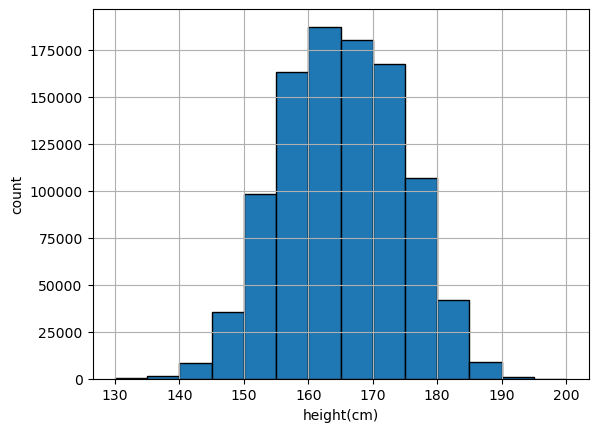

In [23]:
df['신장(5cm단위)'].describe()
x_bins=np.linspace(130, 200, 15)
ax=df['신장(5cm단위)'].hist(bins= x_bins, edgecolor= 'k')
ax.set(xlabel='height(cm)', ylabel='count')

517930 482070


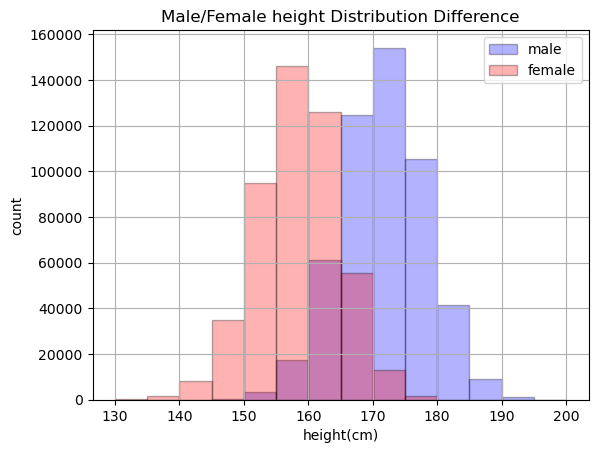

In [ ]:
# Lab : histogram for male and female separately

df_male = df[df['성별코드']==1] #boolean indexing
df_female = df[df['성별코드']==2] #boolean indexing

rty
print(len(df_male), len(df_female))

fig, ax =plt.subplots()
df_male['신장(5cm단위)'].hist(bins = x_bins, ax = ax, color = 'blue', alpha = 0.3, edgecolor = 'k',label = 'male')
df_female['신장(5cm단위)'].hist(bins = x_bins, ax = ax, color = 'red', alpha = 0.3, edgecolor = 'k',label = 'female')
ax.set(xlabel='height(cm)', ylabel='count')
ax.set_title('Male/Female height Distribution Difference')
ax.legend()